# 🦈 Shark Attacks — Exploratory Data Analysis
**Ironhack Data Analytics Bootcamp | Week 2 Project**
**Team:** Diana Carolina Yule Burbano & Irene Fafian

---

### Project Overview
This notebook is the **single merged analysis file** combining both team members' work.

| Section | Content | Contributor |
|---------|---------|-------------|
| 1 | Setup & imports | Both |
| 2 | Dataset import | Both |
| 3 | Initial exploration | Both |
| 4.1–4.2 | Column dropping & naming | Irene |
| 4.3 | String cleaning (Country, State, Location, Fatality) | Irene |
| 4.3 | Activity & Species unification | Irene |
| 4.4 | Type column standardization | Irene |
| 4.5 | Date column — multi-pass parsing | Diana |
| 4.6–4.8 | Deduplication & placeholders | Both |
| 5–8 | EDA, hypothesis validation, conclusions | 📌 Pending |

> **Data source:** [Global Shark Attack File — sharkattackfile.net](https://www.sharkattackfile.net/incidentlog.htm)
> **Module:** All reusable functions are also consolidated in `shark.py` for clean import.


---
## 📋 About the Dataset

The Global Shark Attack File (GSAF) logs shark incidents worldwide. Entries are categorized as follows:

| Category | Description |
|---|---|
| **Unprovoked** | Shark initiated contact without human provocation |
| **Provoked** | Human drew "first blood" (spearing, hooking, capturing) |
| **Watercraft** | Boat bitten or rammed; hooked/netted cases are classed as provoked |
| **Sea Disaster** | Incidents during maritime or aviation accidents |
| **Questionable** | Insufficient data to confirm shark involvement |


---
## 1️⃣ Setup — Imports & Configuration


In [3]:
import pandas as pd
import numpy as np


print('✅ Libraries loaded successfully')


✅ Libraries loaded successfully


---
## 2️⃣ Import Dataset

The file `GSAF5.xls` is stored in the **same folder** as this notebook.
Relative path ensures the notebook runs on any machine that clones the repo.


In [4]:
file_location = 'GSAF5.xls'

shark_df = pd.read_excel(file_location)          # raw — never modify this
shark_clean = shark_df.copy()                    # working copy

print(f'✅ Raw dataset: {shark_df.shape[0]:,} rows × {shark_df.shape[1]} columns')


✅ Raw dataset: 7,087 rows × 23 columns


---
## 3️⃣ Initial Data Exploration

Before cleaning, inspect the raw dataset — structure, column types, completeness.


In [5]:
# First 5 rows
shark_df.head(2)


,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,14/04,2026.0,UNprovoked,Maldives,Gaafu Alif Atoll,Kooddoo,Swimming,Not stated - on honeymoon,M,?,...,Unknown,The U.S. Sun: Simon De Marchi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3rd April,2026.0,Unprovoked,Australia,South Australia,Middleton Beach Fleurieu Peninsula Adelaide,Surfing,Oliver Tokic-Bensley,M,16,...,Bronze Whaler,ABC News: The Guardian: Andrew Currie and Bob...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Data types and non-null counts per column
shark_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7087 entries, 0 to 7086
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            7087 non-null   object 
 1   Year            7085 non-null   float64
 2   Type            7069 non-null   str    
 3   Country         7037 non-null   str    
 4   State           6600 non-null   str    
 5   Location        6520 non-null   str    
 6   Activity        6504 non-null   str    
 7   Name            6869 non-null   str    
 8   Sex             6509 non-null   str    
 9   Age             4093 non-null   object 
 10  Injury          7051 non-null   str    
 11  Fatal Y/N       6526 non-null   object 
 12  Time            3560 non-null   object 
 13  Species         3956 non-null   str    
 14  Source          7067 non-null   object 
 15  pdf             6799 non-null   object 
 16  href formula    6794 non-null   str    
 17  href            6796 non-null   str    
 18 

In [7]:
# Descriptive statistics for categorical columns
shark_df.describe(include='object')

/var/folders/bq/jm95c4z529q6_v32y8vmwlk00000gn/T/ipykernel_8320/2856194318.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  shark_df.describe(include='object')


,Date,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,...,Time,Species,Source,pdf,href formula,href,Case Number,Case Number.1,Unnamed: 21,Unnamed: 22
count,7087,7069,7037,6600,6520,6504,6869,6509,4093,7051,...,3560,3956,7067,6799,6794,6796,6798,6797,1,2
unique,6126,14,253,948,4631,1612,5801,11,252,4197,...,477,1746,5413,6789,6784,6776,6777,6775,1,2
top,1957,Unprovoked,USA,Florida,"New Smyrna Beach, Volusia County",Surfing,male,M,16,FATAL,...,Afternoon,White shark,"K. McMurray, TrackingSharks.com",1935.06.05.R-SolomonIslands.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2021.12.06,2022.03.15,stopped here,Teramo
freq,9,5237,2580,1192,191,1151,679,5682,92,863,...,215,194,131,2,2,4,2,2,1,1


### 🔍 Issues Identified

| Column | Issue | Action |
|---|---|---|
| `Date` | Multiple formats, strings, noise words | Multi-pass parsing → year_ext, month_ext, Season |
| `Year` | Float instead of integer | Convert to Int64 (📌 pending) |
| `Age` | Mixed formats (`?`, `30+`) | Drop — not in business case |
| `Type` | Typos (`UNprovoked`, `Boatomg`) | Map to 5 official GSAF categories |
| `Sex` | 11 unique values | Drop — not in business case |
| `Country` | Punctuation, ambiguous names, geographic entries | String clean + manual mapping |
| `State`, `Location` | Whitespace, casing inconsistencies | Strip + uppercase |
| `Activity` | ~700 unique raw values | Keyword map → 10 standard categories |
| `Species` | ~300 unique raw values | Keyword map → 15 named species |
| `Fatality` | Erroneous values (M, F, NQ, 2017) | Strip + flag |
| `Case Number.1`, `original order` | Redundant / no analytical value | Drop |
| `Unnamed: 21`, `Unnamed: 22` | 1–2 non-null values each | Drop |
| `Name`, `Source`, `pdf`, `href*` | Metadata, not for analysis | Drop |


---
## 4️⃣ Data Cleaning

All cleaning performed step-by-step with reusable functions defined inline.
The same functions are also consolidated in `shark.py` for modular import.

**Cleaning chapters:**
- 4.1 — Drop irrelevant columns
- 4.2 — Standardize column names
- 4.3 — String cleaning: Country, State, Location, Fatality, Activity, Species
- 4.4 — Type column standardization
- 4.5 — Date column: multi-pass parsing → year_ext, month_ext, Season *(Diana)*
- 4.6 — Deduplication check
- 4.7 — 📌 Placeholder: Year dtype fix
- 4.8 — 📌 Placeholder: Additional transformations


---
### 4.1 Drop Irrelevant Columns *(Irene)*

Columns removed based on D1-PLAN.docx YES/NO/MAYBE classification.
Dropped: `Age`, `Name`, `Sex`, `Source`, `Injury`, `pdf`, `href formula`, `href`,
`original order`, `Unnamed: 21`, `Unnamed: 22`.


In [8]:
# Drop columns with no analytical value for our business case (pending to decide wether droping:'Age', 'Name', 'Sex')
cols_to_drop = ['Source', 'Injury', 'pdf',
    'href formula', 'href', 'original order', 'Unnamed: 21', 'Unnamed: 22'
]
shark_clean = shark_clean.drop(columns=cols_to_drop, errors='ignore')

print(f'✅ Columns after dropping: {shark_clean.shape[1]}')
print(list(shark_clean.columns))


✅ Columns after dropping: 15
['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity', 'Name', 'Sex', 'Age', 'Fatal Y/N', 'Time', 'Species ', 'Case Number', 'Case Number.1']


---
### 4.1b Check Case Number — useful as index? *(Irene)*


In [9]:
# Check duplicates on ID columns before deciding to drop them
print('Duplicates in Case Number:', shark_clean.duplicated(subset=['Case Number']).sum())
print('Duplicates in Case Number.1:', shark_clean.duplicated(subset=['Case Number.1']).sum())

# Both are non-unique — not suitable as primary key; drop them
shark_clean = shark_clean.drop(columns=['Case Number', 'Case Number.1'], errors='ignore')
print(f'✅ Remaining columns: {list(shark_clean.columns)}')


Duplicates in Case Number: 309
Duplicates in Case Number.1: 311
✅ Remaining columns: ['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity', 'Name', 'Sex', 'Age', 'Fatal Y/N', 'Time', 'Species ']


---
### 4.2 Standardize Column Names *(Irene)*

Strip whitespace, capitalize first letter. Rename ambiguous `Fatal y/n` → `Fatality`.


In [10]:
def clean_col_name(col):
    """Strip whitespace and capitalize first letter of each column name."""
    return col.strip().capitalize()

shark_clean.columns = shark_clean.columns.map(clean_col_name)

# Rename ambiguous column
shark_clean.rename(columns={'Fatal y/n': 'Fatality'}, inplace=True)

print('✅ Column names standardized:')
print(list(shark_clean.columns))


✅ Column names standardized:
['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity', 'Name', 'Sex', 'Age', 'Fatality', 'Time', 'Species']


---
### 4.3 String Cleaning *(Irene)*

**Technique:** strip whitespace, uppercase normalization, keyword-based category unification.
Helper functions defined once and reused across all string columns.


In [11]:
def clean_string(value):
    """Strip whitespace and convert to uppercase. Returns None for nulls."""
    return value if pd.isnull(value) else str(value).strip().upper()

def find_weird_strings(df, column):
    """
    Identify values containing non-uppercase, non-space characters.
    Useful for spotting typos, punctuation, or encoding issues.
    """
    condition = df[column].apply(
        lambda x: False if pd.isnull(x)
        else any(not (char.isupper() or char.isspace()) for char in str(x))
    )
    return df[condition][column].value_counts()

print('✅ Helper functions defined: clean_string, find_weird_strings')


✅ Helper functions defined: clean_string, find_weird_strings


#### 4.3a Country


In [12]:
# --- Country ---
print(f'Unique countries before: {shark_clean.Country.nunique()}')
shark_clean['Country'] = shark_clean['Country'].apply(clean_string)

# Manual mapping for known ambiguous / multi-name entries
country_map = {
    'ST KITTS ? NEVIS': 'SAINT KITTS AND NEVIS',
    'ST. MARTIN': 'SAINT MARTIN',
    'ST. MAARTIN': 'SAINT MARTIN',
    'TURKS & CAICOS': 'TURKS AND CAICOS ISLANDS',
    'TRINIDAD & TOBAGO': 'TRINIDAD AND TOBAGO',
    'UNITED ARAB EMIRATES (UAE)': 'UNITED ARAB EMIRATES',
    'ST HELENA, BRITISH OVERSEAS TERRITORY': 'SAINT HELENA',
    'CEYLON (SRI LANKA)': 'SRI LANKA',
    'ANDAMAN / NICOBAR ISLANDS': 'INDIA',
    'SUDAN?': 'SUDAN',
    'MID-PACIFC OCEAN': None,
    'ASIA': None,
    'INDIAN OCEAN': None,
    'RED SEA': None,
}
shark_clean['Country'] = shark_clean['Country'].replace(country_map)

def clean_countries(x):
    """Remove ambiguous punctuation and geographic non-countries."""
    if pd.isna(x):
        return None
    x = x.replace('?', '').replace('.', '').replace('&', 'AND')
    if 'BETWEEN' in x:
        return None
    return x.split('/')[0].strip()

shark_clean['Country'] = shark_clean['Country'].apply(clean_countries)
print(f'Unique countries after: {shark_clean.Country.nunique()}')
shark_clean['Country'].value_counts().head(10)


Unique countries before: 253
Unique countries after: 200


Country
USA                 2580
AUSTRALIA           1529
SOUTH AFRICA         599
NEW ZEALAND          146
BAHAMAS              142
PAPUA NEW GUINEA     136
BRAZIL               123
MEXICO               107
ITALY                 73
FIJI                  70
Name: count, dtype: int64

#### 4.3b State & Location


In [13]:
# --- State ---
print(f'Unique State values before: {shark_clean.State.nunique()}')
shark_clean['State'] = shark_clean['State'].apply(clean_string)
print(f'Unique State values after:  {shark_clean.State.nunique()}')

# --- Location ---
print(f'Unique Location values before: {shark_clean.Location.nunique()}')
shark_clean['Location'] = shark_clean['Location'].apply(clean_string)
print(f'Unique Location values after:  {shark_clean.Location.nunique()}')


Unique State values before: 948
Unique State values after:  918
Unique Location values before: 4631
Unique Location values after:  4579


#### 4.3c Fatality


In [14]:
# --- Fatality ---
print(f'Unique Fatality values before: {shark_clean.Fatality.nunique()}')
shark_clean['Fatality'] = shark_clean['Fatality'].apply(clean_string)
print('Value counts after cleaning:')
print(shark_clean['Fatality'].value_counts())

# Rows with clearly erroneous Fatality values
weird_fatal = ['F', 'M', 'NQ', '2017', 'Y X 2']
print(f'\nRows with unexpected Fatality values: {shark_clean[shark_clean["Fatality"].isin(weird_fatal)].shape[0]}')


Unique Fatality values before: 12
Value counts after cleaning:
Fatality
N          4952
Y          1492
UNKNOWN      71
F             5
M             3
NQ            1
2017          1
Y X 2         1
Name: count, dtype: int64

Rows with unexpected Fatality values: 11


#### 4.3d Activity — Keyword Unification

~700 unique raw values unified into 10 standard categories via keyword matching.
Categories: FISHING · SWIMMING · SURFING · DIVING · BOATING · KAYAKING ·
STATIONARY · MARITIME ACCIDENT · OTHER · UNKNOWN


In [15]:
# --- Activity ---
print(f'Unique Activity values before: {shark_clean.Activity.nunique()}')
shark_clean['Activity'] = shark_clean['Activity'].apply(clean_string)

# Keyword-based unification into standard categories
activity_map = {
    'fish': 'FISHING', 'swim': 'SWIMMING', 'bath': 'SWIMMING',
    'surf': 'SURFING', 'board': 'SURFING', 'div': 'DIVING',
    'ship': 'BOATING', 'sail': 'BOATING', 'boat': 'BOATING',
    'kayak': 'KAYAKING', 'canoe': 'KAYAKING',
    'wading': 'STATIONARY', 'stand': 'STATIONARY', 'tread': 'STATIONARY',
    'capsize': 'MARITIME ACCIDENT', 'sank': 'MARITIME ACCIDENT',
    'burn': 'MARITIME ACCIDENT', 'drop': 'MARITIME ACCIDENT',
    'explo': 'MARITIME ACCIDENT', 'fell': 'MARITIME ACCIDENT',
    'fall': 'MARITIME ACCIDENT',
}

def unify_activities(x):
    """Map raw Activity string to a standardized category using keyword matching."""
    if pd.isna(x):
        return 'UNKNOWN'
    x = str(x).lower()
    return next((label for key, label in activity_map.items() if key in x), 'OTHER')

shark_clean['Activity'] = shark_clean['Activity'].apply(unify_activities)
print(f'Unique Activity values after unification: {shark_clean.Activity.nunique()}')
shark_clean['Activity'].value_counts()


Unique Activity values before: 1612
Unique Activity values after unification: 10


Activity
SURFING              1716
SWIMMING             1462
FISHING              1359
OTHER                 748
UNKNOWN               583
DIVING                569
STATIONARY            365
BOATING               159
KAYAKING               71
MARITIME ACCIDENT      55
Name: count, dtype: int64

#### 4.3e Species — Keyword Unification

~300+ unique raw values unified into 15 named species + OTHER + UNKNOWN.
Named: WHITE SHARK · TIGER SHARK · BULL SHARK · HAMMERHEAD · BLACKTIP ·
MAKO · REEF SHARK · SAND SHARK · BLUE SHARK · NURSE SHARK · WOBBEGONG ·
LEMON SHARK · THRESHER SHARK


In [16]:
# --- Species ---
print(f'Unique Species values before: {shark_clean.Species.nunique()}')
shark_clean['Species'] = shark_clean['Species'].apply(clean_string)

# Keyword-based species unification
shark_species_map = {
    'white': 'WHITE SHARK', 'great white': 'WHITE SHARK',
    'tiger': 'TIGER SHARK', 'bull': 'BULL SHARK',
    'hammer': 'HAMMERHEAD SHARK', 'blacktip': 'BLACKTIP SHARK',
    'mako': 'MAKO SHARK', 'reef': 'REEF SHARK',
    'coral reef': 'REEF SHARK', 'whitetip reef': 'REEF SHARK',
    'sand tiger': 'SAND SHARK', 'sandbar': 'SAND SHARK',
    'sand shark': 'SAND SHARK', 'blue': 'BLUE SHARK',
    'nurse': 'NURSE SHARK', 'wobbegong': 'WOBBEGONG SHARK',
    'lemon': 'LEMON SHARK', 'thresher': 'THRESHER SHARK',
}

def unify_species(x):
    """Map raw Species string to a standardized species name using keyword matching."""
    if pd.isna(x):
        return 'UNKNOWN'
    x = str(x).lower()
    return next((label for key, label in shark_species_map.items() if key in x), 'OTHER')

shark_clean['Species'] = shark_clean['Species'].apply(unify_species)
print(f'Unique Species values after unification: {shark_clean.Species.nunique()}')
shark_clean['Species'].value_counts()


Unique Species values before: 1746
Unique Species values after unification: 15


Species
UNKNOWN             3131
OTHER               2002
WHITE SHARK          760
TIGER SHARK          347
BULL SHARK           237
BLACKTIP SHARK       133
NURSE SHARK          113
REEF SHARK            65
BLUE SHARK            61
MAKO SHARK            60
WOBBEGONG SHARK       56
HAMMERHEAD SHARK      49
LEMON SHARK           46
SAND SHARK            23
THRESHER SHARK         4
Name: count, dtype: int64

---
### 4.4 Type Column — 5 Official GSAF Categories *(Irene)*

Fixes typos (`UNprovoked`, `Boatomg`) and normalizes casing.
Official categories: `Unprovoked`, `Provoked`, `Watercraft`, `Sea Disaster`, `Questionable`.


In [17]:
# Fix typos and unify casing in the Type column
type_mapping = {
    'UNprovoked': 'Unprovoked', 'unprovoked': 'Unprovoked', 'UNPROVOKED': 'Unprovoked',
    'provoked': 'Provoked', 'PROVOKED': 'Provoked',
    'Boatomg': 'Watercraft',
    'Sea Disaster': 'Sea Disaster',
    'Invalid': 'Questionable',
}
shark_clean['Type'] = shark_clean['Type'].replace(type_mapping)

print('Type value counts after cleaning:')
print(shark_clean['Type'].value_counts(dropna=False))


Type value counts after cleaning:
Type
Unprovoked             5239
Provoked                642
Questionable            578
Watercraft              355
Sea Disaster            242
NaN                      18
Boat                      7
 Provoked                 2
?                         1
Unconfirmed               1
Unverified                1
Under investigation       1
Name: count, dtype: int64


---
### 4.5 Date Column — Multi-Pass Parsing *(Diana)*

The `Date` column contains 130 years of free-text entries in dozens of inconsistent formats.
A 4-step pipeline extracts clean `year_ext`, `month_ext`, and `Season` columns.

**Pipeline:**
1. `month_year()` — remove ordinal suffixes, normalize to 'Mon YYYY' format
2. `word_cleaner()` — strip noise words (Before, Circa, Reported…) from unparseable rows
3. `recog_daytimef()` — convert parseable strings to datetime objects
4. `ext_year_month()` — extract `year_ext` and `month_ext`, handle epoch artifacts
5. Derive `Season` from `month_ext` for H2 temporal analysis


In [18]:
def month_year(val):
    """
    # Extracts month and year in int
    """
    if not isinstance(val, str):
        return val
    
    months = ["january","february","march","april","may","june",
              "july","august","september","October","november","december","jan","feb","mar","apr","may","jun",
              "jul","aug","sep","oct","nov","dec"]
    
    suffixes = ["st","nd","rd","th"]
    
    # Remove ordinal suffixes
    for s in suffixes:
        val = val.replace(s, "")
    
    val = val.strip()
    
    # Detect "MonthName DD" → flip to "DD MonthName"
    parts = val.lower().split()
    if len(parts) == 2:
        if parts[1].isdigit() and len(parts[1])<=2 and parts[0] in months:
            val = f"{parts[0]}"   # "was April 3, changed to april"
        elif parts[0].isdigit() and len(parts[0])<=2 and parts[1] in months:
            val = f"{parts[1]}"
        else:
            pass
            
    # Detect formats like "DD-MM-YYYY" 09-jun-2001 or 2001-jun-01
    parts = val.lower().replace('-',' ').split()
    if len(parts) == 3:
        #09-jun-2001
        if parts[1] in months and parts[2].isdigit() and len(parts[2])==4:
            val = f"{parts[1]} {parts[2]}"
        elif parts[0].isdigit() and len(parts[0])==4 and parts[1] in months:
            val = f"{parts[1]} {parts[0]}" #was 2001-jun-01 and becomes jun-2001
        else:
            pass

    # Detect formats like "YYYY- YYYY"
    if len(parts) == 2:
  
        if parts[0].isdigit() and parts[1].isdigit() and  len(parts[0])==4 and len(parts[1])==4:
            val = round((int(parts[0])+int(parts[1]))/2)
        elif parts[0].isdigit() and len(parts[0])==4 and parts[1] in months:
            val = f"{parts[1]} {parts[0]}" #was 2001-jun-01 and becomes jun-2001
        else:
            pass
    
    return val

def month_year_f(df: pd.DataFrame,col_date) ->pd.DataFrame:
    
    df1=df.copy()
    df1[col_date] = df1[col_date].apply(month_year)

    return df1

In [19]:
from dateutil import parser 
def flex_dateparse(text):
   
    try:
        # fuzzy=True allows it to ignore words like "Reported" or "Ca.", "Late"

        return parser.parse(text, fuzzy=True)
    except:
        return None
        
def smart_cleaner(df,col_date):
    df1=df.copy()
    df1['fdate_check']=pd.to_datetime(df1[col_date], errors='coerce',dayfirst=True)
    mask= df1['fdate_check'].isnull()
    # Apply only to rows where the first pass failed
    df1.loc[mask, col_date] = df1.loc[mask,col_date].apply(flex_dateparse)
    df1=df1.drop('fdate_check',axis=1)
    return df1


In [20]:
def word_cleaner(df,col_date, words_remove) ->pd.DataFrame:
    """
    df: The DataFrame
    target_col: The column you want to fix (e.g., 'Date')
    words_remove: List of strings to delete
    """
    df1=df.copy()
    df1['fdate_check']=pd.to_datetime(df1[col_date], errors='coerce',dayfirst=True)
    pattern='|'.join(words_remove)
    mask = df1['fdate_check'].isnull()
    df1.loc[mask,col_date]=df1.loc[mask,col_date].str.replace(pattern,'',regex=True).str.strip()
    df1=df1.drop('fdate_check',axis=1)
    return df1

In [21]:
def recog_daytimef(df,col_date):
    """
## returns a copy of df which contains a new coloumn indicating NaT if the format if
#datetime cannot be determined. Also, returns a series of the rows from col_date for which NaN is present and which need fixing.
#errors='coerce' → if it can't parse, it writes NaT (= "unknown") instead of crashing
    """
    df1=df.copy()
    df1['fdate_check']=pd.to_datetime(df1[col_date], errors='coerce',dayfirst=True)
    mask = df1['fdate_check'].isnull()==False
    df1.loc[mask,'Date']=df1.loc[mask,'fdate_check']
    #df1= df1.drop('fdate_check', axis=1)
    return df1

In [22]:
# Month name mapping
month_map = {
    'jan': 1, 'january': 1,
    'feb': 2, 'february': 2,
    'mar': 3, 'march': 3,
    'apr': 4, 'april': 4, 'ap':4,
    'may': 5,
    'jun': 6, 'june': 6,
    'jul': 7, 'july': 7,
    'aug': 8, 'august': 8, 'augu':8,
    'sep': 9, 'september': 9,
    'oct': 10, 'october': 10,
    'nov': 11, 'november': 11,
    'dec': 12, 'december': 12
}

def ext_year_month(date_val, fallback_year):
    date_str = str(date_val).strip().lower()

    # Trying direct datetime parse first ---
    parsed = pd.to_datetime(date_str, errors='coerce')
    
    # Excluding epoch artifacts (1970 with microsecond-encoded year)
    if parsed is not pd.NaT and parsed.year != 1970:
        return parsed.year, parsed.month

    # Month name only (e.g. "april", "jun") ---
    for name, num in month_map.items():
        if name in date_str:
            return fallback_year, num
        

    # Epoch artifact "1970-01-01 00:00:00.000001902"
    # microseconds field has the real year as last 4 digits
    if '1970' in date_str and '.' in date_str:
        micro_str = date_str.split('.')[-1]  # "000001902"
        year = micro_str[-4:]               # "1902"
        return int(year) if year.isdigit() else fallback_year, None

    return fallback_year, None

In [23]:
# STEP 1 — Apply month_year normalisation
shark_clean = month_year_f(shark_clean, 'Date')
print(f'Unique Date values after step 1: {shark_clean.Date.nunique()}')
shark_clean['Date'].value_counts().head(10)


Unique Date values after step 1: 2726


Date
apr 2017    21
jun 2015    21
jul 2021    19
jul 2016    19
aug 2014    19
jan 1962    19
jul 2022    18
jul 2015    18
jun 2012    18
sep 2007    18
Name: count, dtype: int64

In [24]:
# STEP 2 — Remove noise words from remaining unparseable dates
w_remove = [
    'Before', 'Reported', 'of', 'No date', 'Circa',
    'Prior to', 'After', 'or', 'late', 'A few years before',
    'Between', 'After Augu', 'before', 'Said to be'
]
shark_clean = word_cleaner(shark_clean, 'Date', w_remove)


/var/folders/bq/jm95c4z529q6_v32y8vmwlk00000gn/T/ipykernel_8320/239534973.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1['fdate_check']=pd.to_datetime(df1[col_date], errors='coerce',dayfirst=True)


In [25]:
# STEP 3 — Convert parseable strings to datetime objects
shark_clean = recog_daytimef(shark_clean, 'Date')


/var/folders/bq/jm95c4z529q6_v32y8vmwlk00000gn/T/ipykernel_8320/2929492904.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1['fdate_check']=pd.to_datetime(df1[col_date], errors='coerce',dayfirst=True)


In [26]:
# STEP 4 — Extract year_ext and month_ext from cleaned Date
shark_clean[['year_ext', 'month_ext']] = shark_clean.apply(
    lambda row: pd.Series(ext_year_month(row['Date'], row['Year'])), axis=1
)

# Derive Season from month_ext (for H2 analysis)
season_map = {
    1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring',
    5: 'Spring', 6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn', 12: 'Winter'
}
shark_clean['Season'] = shark_clean['month_ext'].map(season_map)

print(f'Rows with unresolved year (year_ext == 0): {(shark_clean.year_ext == 0).sum()}')
shark_clean[['Date', 'Year', 'year_ext', 'month_ext', 'Season']].head(10)


Rows with unresolved year (year_ext == 0): 30


,Date,Year,year_ext,month_ext,Season
0,14/04,2026.0,2026.0,NaN,NaN
1,april,2026.0,1.0,4.0,Spring
2,march,2026.0,1.0,3.0,Spring
3,march,2026.0,1.0,3.0,Spring
4,2022-03-23 00:00:00,2026.0,2022.0,3.0,Spring
5,march,2026.0,1.0,3.0,Spring
6,march,2026.0,1.0,3.0,Spring
7,march,2026.0,1.0,3.0,Spring
8,march,2026.0,1.0,3.0,Spring
9,february,2026.0,1.0,2.0,Winter


In [27]:
#The dataset now has cleaner columns, we check now that:
#* the type of the columns we want to use have the correct type
#* the columns we need to drop

shark_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 7087 entries, 0 to 7086
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         7087 non-null   object        
 1   Year         7085 non-null   float64       
 2   Type         7069 non-null   str           
 3   Country      7027 non-null   str           
 4   State        6600 non-null   str           
 5   Location     6520 non-null   str           
 6   Activity     7087 non-null   str           
 7   Name         6869 non-null   str           
 8   Sex          6509 non-null   str           
 9   Age          4093 non-null   object        
 10  Fatality     6526 non-null   str           
 11  Time         3560 non-null   object        
 12  Species      7087 non-null   str           
 13  fdate_check  6857 non-null   datetime64[ns]
 14  year_ext     7087 non-null   float64       
 15  month_ext    6758 non-null   float64       
 16  Season       6758

In [28]:
# Drop columns with no analytical value at this stage, after cleaning
cols_drop = ['Date','Year', 'Time', 'fdate_check']
shark_clean= shark_clean.drop(columns=cols_drop, errors='ignore')

# format column names for easy handling
shark_clean=shark_clean.rename(columns={'year_ext':'year','month_ext':'month'})
shark_clean.columns=shark_clean.columns.map(lambda x: x.lower())
shark_clean.head()
#print(f'✅ Columns after dropping: {shark_clean.shape[1]}')
#print(list(shark_clean.columns))

,type,country,state,location,activity,name,sex,age,fatality,species,year,month,season
0,Unprovoked,MALDIVES,GAAFU ALIF ATOLL,KOODDOO,SWIMMING,Not stated - on honeymoon,M,?,N,OTHER,2026.0,NaN,NaN
1,Unprovoked,AUSTRALIA,SOUTH AUSTRALIA,MIDDLETON BEACH FLEURIEU PENINSULA ADELAIDE,SURFING,Oliver Tokic-Bensley,M,16,N,OTHER,1.0,4.0,Spring
2,Unprovoked,BAHAMAS,ANDROS ISLAND,FRESH CREEK,SWIMMING,Australian woman,F,22,N,OTHER,1.0,3.0,Spring
3,Unprovoked,AUSTRALIA,SOUTH AUSTRALIA,CAPE JAFFA LIMESTONE COAST,DIVING,Luke Kuhn,M,?,N,WHITE SHARK,1.0,3.0,Spring
4,Unprovoked,AUSTRALIA,NSW,LITTLE AVALON BEACH,SURFING,Unknown,M,30+,N,OTHER,2022.0,3.0,Spring


---
### 4.6 Deduplication *(Both)*


In [29]:
#After having cleaned many data, we proceed to check for duplicates with the remaining columns to later drop the necessary rows.

In [30]:
# Check for fully duplicate rows
n_dupes = shark_clean.duplicated().sum()
print(f'Fully duplicate rows: {n_dupes}')

if n_dupes > 0:
    shark_clean = shark_clean.drop_duplicates()
    print(f'✅ Duplicates removed. Shape now: {shark_clean.shape}')
else:
    print('✅ No duplicates found.')

print(f'\nCleaned dataset, no duplicate based on each column: {shark_clean.shape[0]:,} rows × {shark_clean.shape[1]} columns')

shark_clean.info()

Fully duplicate rows: 6
✅ Duplicates removed. Shape now: (7081, 13)

Cleaned dataset, no duplicate based on each column: 7,081 rows × 13 columns
<class 'pandas.DataFrame'>
Index: 7081 entries, 0 to 7086
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   type      7063 non-null   str    
 1   country   7021 non-null   str    
 2   state     6595 non-null   str    
 3   location  6515 non-null   str    
 4   activity  7081 non-null   str    
 5   name      6863 non-null   str    
 6   sex       6503 non-null   str    
 7   age       4093 non-null   object 
 8   fatality  6520 non-null   str    
 9   species   7081 non-null   str    
 10  year      7081 non-null   float64
 11  month     6753 non-null   float64
 12  season    6753 non-null   str    
dtypes: float64(2), object(1), str(10)
memory usage: 774.5+ KB


In [31]:
# Now that we drop all the duplicates also considering columns name, age, sex, we can drop them as their data is not relevant for our Busines Case.
cols_drop = ['name','age', 'sex']
shark_clean= shark_clean.drop(columns=cols_drop, errors='ignore')
print(f'\nFinal cleaned dataset, no duplicates correct dtypes: {shark_clean.shape[0]:,} rows × {shark_clean.shape[1]} columns')
shark_clean.head(2)



Final cleaned dataset, no duplicates correct dtypes: 7,081 rows × 10 columns


,type,country,state,location,activity,fatality,species,year,month,season
0,Unprovoked,MALDIVES,GAAFU ALIF ATOLL,KOODDOO,SWIMMING,N,OTHER,2026.0,NaN,NaN
1,Unprovoked,AUSTRALIA,SOUTH AUSTRALIA,MIDDLETON BEACH FLEURIEU PENINSULA ADELAIDE,SURFING,N,OTHER,1.0,4.0,Spring


In [32]:
#As our analysis will be based on seasons, time, we need to ensure we have filled those columns:
no_date=len(shark_clean[
    (shark_clean['year'].isnull() | (shark_clean['year'] == 0)) &
    (shark_clean['month'].isnull() | (shark_clean['month'] == 0)).sum()])
print(f"There are {no_date} rows where there is no valid year and month as either is empty or 0")


There are 0 rows where there is no valid year and month as either is empty or 0


In [33]:
#Proceed to drop all those where no month or year is known, specially if they are few of them no harm.
#We drop those rows using the mask's index
mask=shark_clean[
    (shark_clean['year'].isnull() | (shark_clean['year'] == 0)) &
    (shark_clean['month'].isnull() | (shark_clean['month'] == 0))]

shark_clean = shark_clean.drop(index=mask.index)
#Now let's see what is left
no_year= shark_clean[
    (shark_clean['year'].isnull()) | (shark_clean['year'] == 0)]
print(f"After cleaning are {len(no_year)} rows where year is null or 0")

no_month= shark_clean[
    (shark_clean['month'].isnull()) | (shark_clean['month'] == 0)]

print(f"After cleaning are {len(no_month)} rows where month is null or 0")

After cleaning are 2 rows where year is null or 0
After cleaning are 300 rows where month is null or 0


In [34]:
#We drop the 2 rows where year is missing, specially as they are just 2. We keep month as they are mores significant in number,
#we later will see how we fill or replace those, in case we see the need.
shark_clean = shark_clean.drop(index=no_year.index)

#reseting also indexes
shark_clean=shark_clean.reset_index()

In [35]:
print("After all the cleaning done we have changed from:")
print(f'✅ Raw dataset: {shark_df.shape[0]:,} rows × {shark_df.shape[1]} columns')
print("to this:")
print(f'✅ Clean dataset: {shark_clean.shape[0]:,} rows × {shark_clean.shape[1]} columns')

After all the cleaning done we have changed from:
✅ Raw dataset: 7,087 rows × 23 columns
to this:
✅ Clean dataset: 7,051 rows × 11 columns


---
### 4.7 📌 Placeholder — Year / Numeric Type Fixes
> *To be completed: convert Year to Int64, validate year_ext range, handle extreme dates (pre-1900).*


In [36]:
#Now we need to decide from all the 7081 which are relevant, as climate changes has changed the conditions of the worl,
print("we will focus only on the data from the current century from 2000 onwards, that means that our data set characterisctics are:")
print(shark_clean[shark_clean['year']>=2000].info())

we will focus only on the data from the current century from 2000 onwards, that means that our data set characterisctics are:
<class 'pandas.DataFrame'>
Index: 2791 entries, 0 to 6983
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   index     2791 non-null   int64  
 1   type      2777 non-null   str    
 2   country   2787 non-null   str    
 3   state     2672 non-null   str    
 4   location  2679 non-null   str    
 5   activity  2791 non-null   str    
 6   fatality  2610 non-null   str    
 7   species   2791 non-null   str    
 8   year      2791 non-null   float64
 9   month     2787 non-null   float64
 10  season    2787 non-null   str    
dtypes: float64(2), int64(1), str(8)
memory usage: 261.7 KB
None


---
### 4.8 📌 Placeholder — Additional Transformations Before Analysis
> *Any remaining cleaning, feature engineering, or data shaping needed before EDA goes here.*


In [37]:
# 📌 Cleaning data set to work only with data from 2000 onwards 
shark_newera=shark_clean.copy()
old_data=shark_newera[shark_newera['year']<2000]
shark_newera= shark_newera.drop(index=old_data.index)


---
### ✅ Cleaning Summary

| Step | Column(s) | Technique | Status |
|------|-----------|-----------|--------|
| 4.1 | Multiple | Column dropping | ✅ Done |
| 4.2 | All | Column renaming / capitalize | ✅ Done |
| 4.3 | Country, State, Location, Fatality, Activity, Species | String cleaning + keyword mapping | ✅ Done |
| 4.4 | Type | Typo fix + category standardization | ✅ Done |
| 4.5 | Date | Multi-pass date parsing → year_ext, month_ext, Season | ✅ Done |
| 4.6 | All | Deduplication | ✅ Done |
| 4.7 | Year | Dtype conversion + range validation | 📌 Pending |
| 4.8 | TBD | Additional transformations for EDA | 📌 Pending |


---
### ✅ Cleaned Dataset — Quick Inspection


In [38]:
# Final shape and column overview after full cleaning
print(f'Shape: {shark_clean.shape[0]:,} rows × {shark_clean.shape[1]} columns')
print(f'Columns: {list(shark_clean.columns)}')
shark_clean.dtypes


Shape: 7,051 rows × 11 columns
Columns: ['index', 'type', 'country', 'state', 'location', 'activity', 'fatality', 'species', 'year', 'month', 'season']


index         int64
type            str
country         str
state           str
location        str
activity        str
fatality        str
species         str
year        float64
month       float64
season          str
dtype: object

In [39]:
shark_clean.head()


,index,type,country,state,location,activity,fatality,species,year,month,season
0,0,Unprovoked,MALDIVES,GAAFU ALIF ATOLL,KOODDOO,SWIMMING,N,OTHER,2026.0,NaN,NaN
1,1,Unprovoked,AUSTRALIA,SOUTH AUSTRALIA,MIDDLETON BEACH FLEURIEU PENINSULA ADELAIDE,SURFING,N,OTHER,1.0,4.0,Spring
2,2,Unprovoked,BAHAMAS,ANDROS ISLAND,FRESH CREEK,SWIMMING,N,OTHER,1.0,3.0,Spring
3,3,Unprovoked,AUSTRALIA,SOUTH AUSTRALIA,CAPE JAFFA LIMESTONE COAST,DIVING,N,WHITE SHARK,1.0,3.0,Spring
4,4,Unprovoked,AUSTRALIA,NSW,LITTLE AVALON BEACH,SURFING,N,OTHER,2022.0,3.0,Spring


---
## 5️⃣ Exploratory Data Analysis (EDA)

With the cleaned dataset, we now explore distributions and patterns to form hypotheses.

> 📌 **Status:** EDA section to be completed after EDA module.
> Placeholder cells below — add analysis code here.
> Columns ready for analysis: `Country`, `Type`, `Activity`, `Species`,
> `Fatality`, `year_ext`, `month_ext`, `Season`.


type
Unprovoked          5210
Provoked             643
Boating incident     600
Unknown               16
Questionable           4
Name: count, dtype: int64

type
Unprovoked          5210
Provoked             643
Boating incident     600
Unknown              578
Name: count, dtype: int64

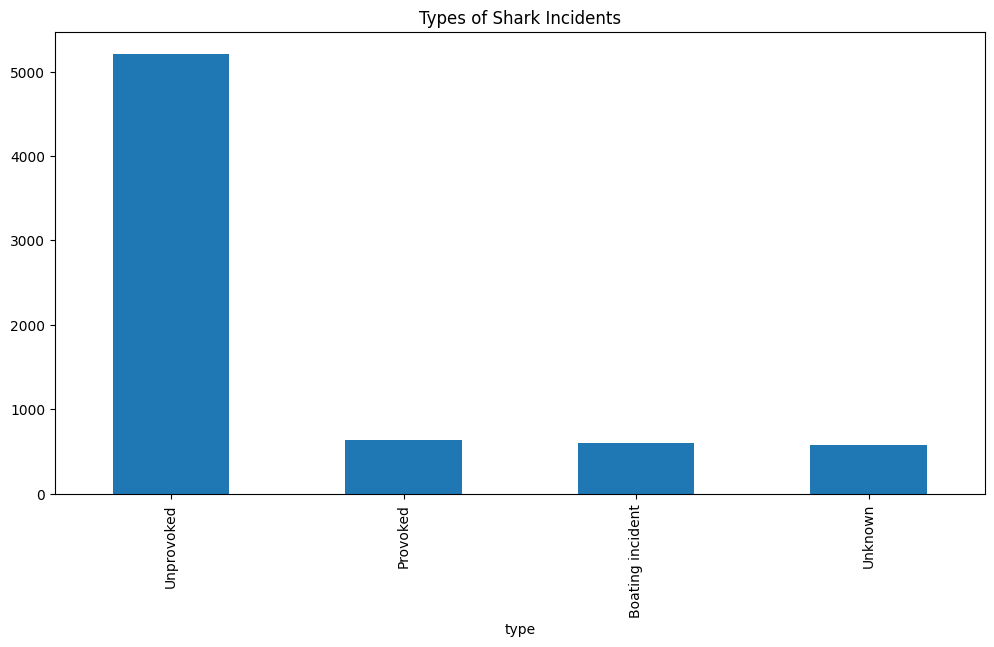

In [97]:
# 📌 PLACEHOLDER — incident type distribution **IMPORTANT: cleaning of the types included
# shark_clean['Type'].value_counts()

display(shark_clean['type'].value_counts())

#CLEANING
type_map = {'unprovoked': 'Unprovoked','provoked': 'Provoked','?': 'Questionable','unconfirmed': 'Questionable','unverified': 'Questionable','under investigation': 'Questionable','watercraft': 'Boating incident','sea disaster': 'Boating incident','boat': 'Boating incident'}

def clean_type(x):
    if pd.isna(x):
        return 'Unknown'
    x = str(x).lower()
    return next((label for key, label in type_map.items() if key in x), None)

shark_clean['type'] = shark_clean['type'].apply(clean_type)
# CLEANING FINISHES

type_counts = (shark_clean['type'].value_counts().head(10))
type_counts.plot(kind='bar',figsize=(12,6),title='Types of Shark Incidents')

display(shark_clean['type'].value_counts())

activity
SURFING              1713
SWIMMING             1455
FISHING              1351
OTHER                 744
UNKNOWN               581
DIVING                561
STATIONARY            363
BOATING               157
KAYAKING               71
MARITIME ACCIDENT      55
Name: count, dtype: int64

<Axes: title={'center': 'Top 10 Activities Associated with Shark Incidents'}, xlabel='activity'>

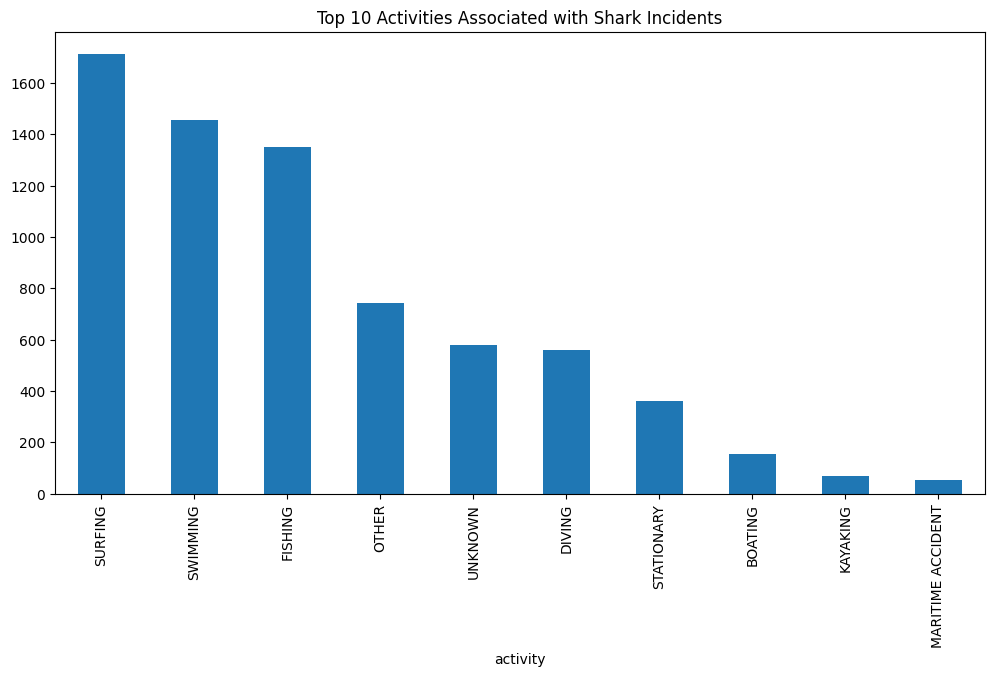

In [86]:
# 📌 PLACEHOLDER — top 10 activities
import seaborn as sns
display(shark_clean['activity'].value_counts().head(10))
activity_counts = (shark_clean['activity'].value_counts().head(10))

activity_counts.plot(kind='bar',figsize=(12,6),title='Top 10 Activities Associated with Shark Incidents')

country
USA              1336
AUSTRALIA         562
SOUTH AFRICA      156
BAHAMAS            84
BRAZIL             66
NEW ZEALAND        61
MEXICO             42
NEW CALEDONIA      39
EGYPT              33
REUNION            31
Name: count, dtype: int64

<Axes: title={'center': 'Top 10 Countries Associated with Shark Incidents'}, xlabel='country'>

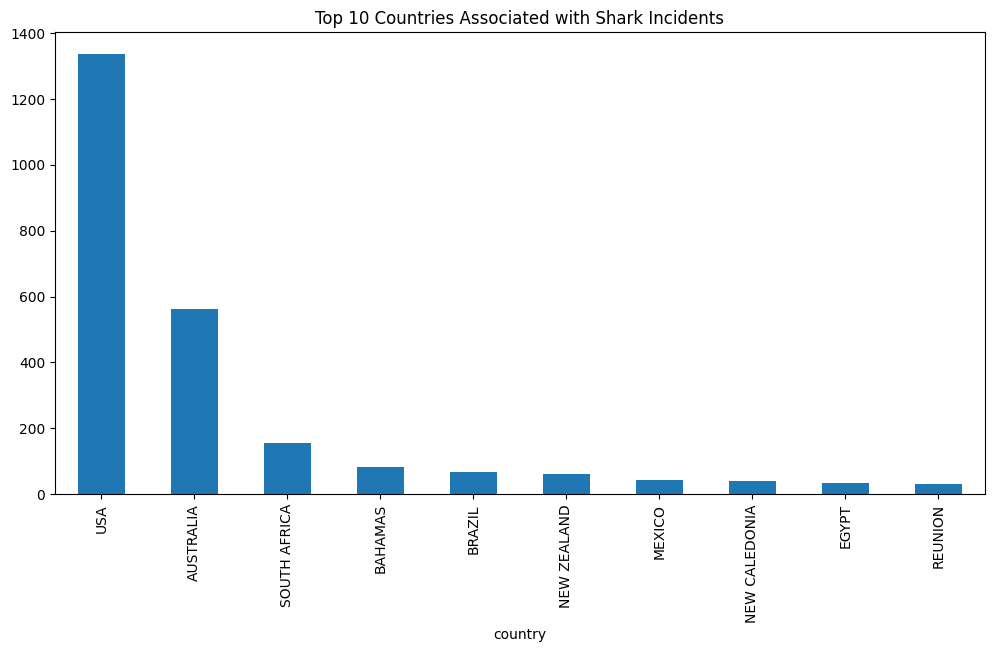

In [90]:
# 📌 PLACEHOLDER — top 10 countries
# filtered for values only after the year 2000:
geo_df = shark_clean[shark_clean['year'] >= 2000].copy()
# Sort by frequency of country:
geo_df = geo_df.sort_values(by='country',key=lambda x: x.value_counts().reindex(x),ascending=False)
country_counts = geo_df['country'].value_counts()
display(country_counts.head(10))
country_counts.head(10).plot(kind='bar',figsize=(12,6), title='Top 10 Countries Associated with Shark Incidents')

In [79]:
top10_share = (geo_df['country'].value_counts(normalize=True).head(10).sum())
top1_share = (geo_df['country'].value_counts(normalize=True).head(1).sum())

print(f'The top 10 countries account for {(top10_share*100).round(2)}% of all recorded incidents after 2000.')
print(f'The country with most incidents recorded since 2000 accounts for {(top1_share*100).round(2)}% of all recorded incidents.')

The top 10 countries account for 86.47% of all recorded incidents after 2000.
The country with most incidents recorded since 2000 accounts for 47.94% of all recorded incidents.


,country,location,incident_count
1345,USA,"NEW SMYRNA BEACH, VOLUSIA COUNTY",151
1460,USA,"PONCE INLET, VOLUSIA COUNTY",22
1000,USA,"COCOA BEACH, BREVARD COUNTY",18
1322,USA,"MYRTLE BEACH, HORRY COUNTY",17
1297,USA,"MELBOURNE BEACH, BREVARD COUNTY",16
1030,USA,"DAYTONA BEACH, VOLUSIA COUNTY",13
1161,USA,"ISLE OF PALMS, CHARLESTON COUNTY",12
1164,USA,"JACKSONVILLE BEACH, DUVAL COUNTY",11
1459,USA,"PONCE INLET, NEW SMYRNA BEACH, VOLUSIA COUNTY",9
1339,USA,NEW SMYRNA BEACH,8


<Axes: ylabel='location'>

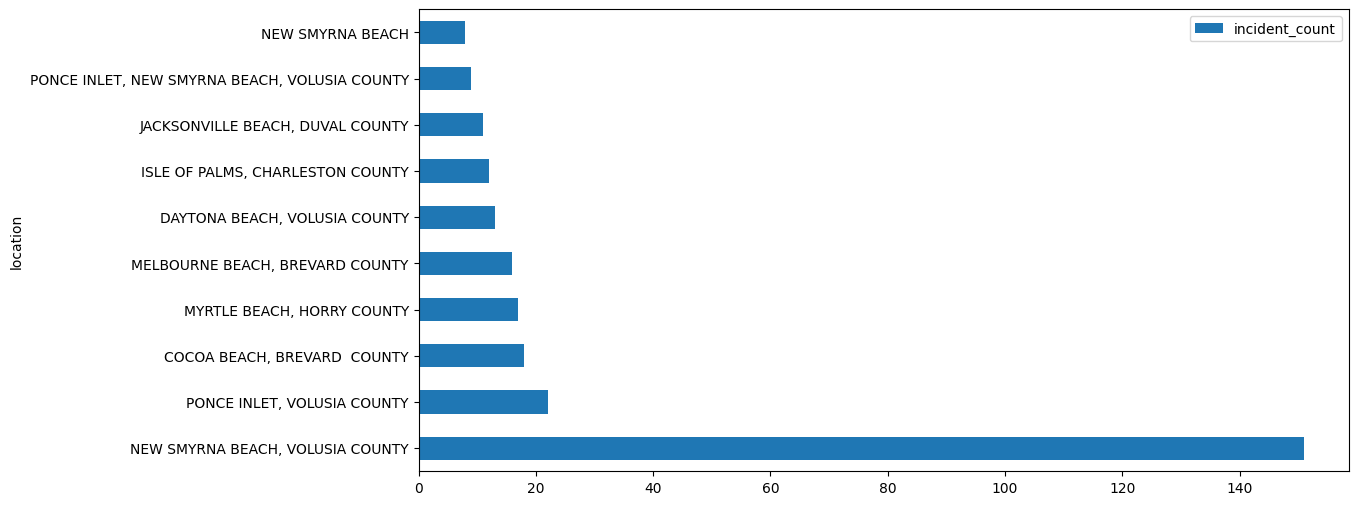

In [92]:
# top locations by country (only top 10 countries):
top10_countries = (geo_df['country'].value_counts().head(10).index)
top10_countries
geo_top10 = geo_df[geo_df['country'].isin(top10_countries)].copy()
country_location_counts = (geo_top10.groupby(['country', 'location']).size().reset_index(name='incident_count'))
display(country_location_counts.sort_values(by='incident_count', ascending=False).head(10))

top_locations=country_location_counts.sort_values('incident_count', ascending=False).head(10)
top_locations.plot(kind='barh',x='location',y='incident_count',figsize=(12,6))

species
UNKNOWN           3103
OTHER             2000
WHITE SHARK        760
TIGER SHARK        345
BULL SHARK         235
BLACKTIP SHARK     133
NURSE SHARK        113
REEF SHARK          65
MAKO SHARK          60
BLUE SHARK          60
Name: count, dtype: int64

<Axes: title={'center': 'Top 10 Shark Spieces Associated with Shark Incidents'}, xlabel='species'>

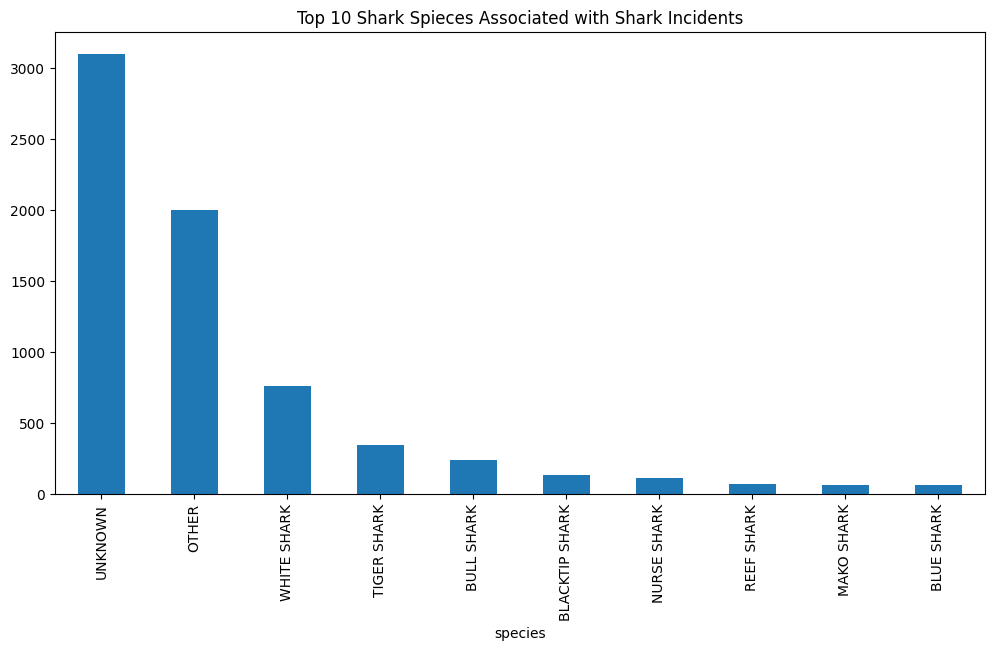

In [87]:
# 📌 PLACEHOLDER — species distribution
# shark_clean['Species'].value_counts()
display(shark_clean['species'].value_counts().head(10))
species_counts = (shark_clean['species'].value_counts().head(10))
species_counts.plot(kind='bar',figsize=(12,6),title='Top 10 Shark Spieces Associated with Shark Incidents')

In [45]:
# 📌 PLACEHOLDER — seasonal distribution (uses Season / month_ext from 4.5)
#As there are months=nan, we check what is the mode for the data set
display(shark_clean['season'].unique())
shark_clean[shark_clean['season'].isnull()]


array([nan, 'Spring', 'Winter', 'Autumn', 'Summer'], dtype=object)

,index,type,country,state,location,activity,fatality,species,year,month,season
0,0,Unprovoked,MALDIVES,GAAFU ALIF ATOLL,KOODDOO,SWIMMING,N,OTHER,2026.0,NaN,NaN
2053,2053,Provoked,USA,FLORIDA,"OFF FORT PIERCE, ST. LUCIE COUNTY",FISHING,N,NURSE SHARK,2008.0,NaN,NaN
2054,2054,Unprovoked,MEXICO,BAJA CALIFORNIA,PLAYAS DE TIJUANA,SURFING,N,HAMMERHEAD SHARK,2008.0,NaN,NaN
2900,2900,Questionable,USA,VIRGINIA,"SANDRIDGE BEACH, VIRGINIA BEACH, PRINCESS ANNE...",SURFING,NaN,OTHER,1999.0,NaN,NaN
2964,2964,Unprovoked,REUNION,BEAUFONDS,NaN,DIVING,Y,UNKNOWN,1998.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
7029,7054,Sea Disaster,PACIFIC OCEAN,NaN,NaN,UNKNOWN,Y,UNKNOWN,1943.0,NaN,NaN
7034,7067,Unprovoked,AUSTRALIA,QUEENSLAND,GREAT BARRIER REEF,UNKNOWN,Y,UNKNOWN,1922.0,NaN,NaN
7048,7084,Unprovoked,USA,NORTH CAROLINA,OCRACOKE INLET,SWIMMING,Y,UNKNOWN,1902.0,NaN,NaN
7049,7085,Unprovoked,PANAMA,NaN,"PANAMA BAY 8ºN, 79ºW",UNKNOWN,Y,UNKNOWN,1886.0,NaN,NaN


In [ ]:
# 📌 PLACEHOLDER — incidents over time
# shark_clean['year_ext'].value_counts().sort_index()


---
## 6️⃣ Hypothesis Validation

We test the following hypotheses using aggregation and filtering:

### 🔬 Hypothesis 1 — Geographic Hotspots
> **H1:** Shark incidents (provoked and unprovoked) are more frequently recorded in specific
> coastal regions, indicating that certain areas are structurally higher-risk due to
> environmental or ecological conditions.
>
> *Status: 📌 To be validated in EDA phase*


In [ ]:
# 📌 PLACEHOLDER — H1: Geographic Hotspots
# top_countries = shark_clean['Country'].value_counts(dropna=True).head(10)
# pct_top5 = top_countries.head(5).sum() / len(shark_clean.dropna(subset=['Country'])) * 100
# print(top_countries)
# print(f'Top 5 countries = {pct_top5:.1f}% of all incidents')


### 🔬 Hypothesis 2 — Seasonal / Temporal Patterns
> **H2:** Shark incidents are more common during specific times of year, suggesting that seasonal
> behavioural patterns (mating, migration, feeding cycles) influence the likelihood of encounters.
>
> *Status: 📌 To be validated in EDA phase — requires year_ext / month_ext columns from 4.5*


In [ ]:
# 📌 PLACEHOLDER — H2: Seasonal Patterns
# Uses year_ext / month_ext / Season columns derived in 4.5
# shark_clean['Season'].value_counts()
# shark_clean['month_ext'].value_counts().sort_index()


### 🔬 Hypothesis 3 — Species: Variety vs. Quantity
> **H3:** Is a more varied sample of shark species preferable to a large volume of a single type?
> Testing whether species diversity correlates with incident patterns.
>
> *Status: 📌 To be validated — requires Species column from 4.3*


In [ ]:
# 📌 PLACEHOLDER — H3: Species Variety vs. Quantity
# shark_clean['Species'].value_counts()
# known = shark_clean[shark_clean['Species'] != 'UNKNOWN']
# print(f'Identified species records: {len(known)} of {len(shark_clean)}')


---
## 7️⃣ Aggregation & Pivot Tables

In [ ]:
# 📌 PLACEHOLDER — Country × Type pivot table
# top8 = shark_clean['Country'].value_counts(dropna=True).head(8).index
# pivot = pd.pivot_table(
#     shark_clean[shark_clean['Country'].isin(top8)],
#     index='Country', columns='Type',
#     values='Season', aggfunc='count', fill_value=0
# )
# pivot


---
## 8️⃣ Key Insights & Conclusions

> ⚠️ **Work in Progress** — this section will be completed once EDA and hypothesis validation are done.

**Planned conclusions structure:**
1. **H1 — Geography:** *[To be filled after country/region aggregation]*
2. **H2 — Seasonality:** *[To be filled after month/season distribution analysis]*
3. **H3 — Species:** *[To be filled after species frequency + diversity analysis]*
4. **Data quality notes:** Heavy cleaning required — Date, Type, Country, Activity, Species.
   Approximately X% of rows had missing or unparseable dates (handled via year_ext column).

---
*Notebook by Diana Carolina Yule Burbano & Irene Fafian — Ironhack Data Analytics Bootcamp, Week 2*


In [ ]:
# End of notebook — cleaning complete, analysis pending
print(f'Cleaned dataset ready: {shark_clean.shape[0]:,} rows × {shark_clean.shape[1]} columns')
print(f'Columns: {list(shark_clean.columns)}')
